# Exploring the 3W dataset

In [ ]:
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import CleanSignalsConfig, FillLabelsConfig, ImputeMissingConfig

In this notebook, we will explore the *3W dataset* by examining missing data, analyzing the average values of the features, and demonstrating a simple example of data cleaning.

---------

## Loading the dataset

Define the folder where your dataset is stored. If the dataset is not found there, it will be downloaded automatically.
Let's load the dataset in its raw format, without any data cleaning:

In [2]:
# Modify this path to the folder where your dataset is downloaded
dataset_path = "../../dataset"
ds = ParquetDatasetConfig(path=dataset_path).build()

print("--------------------------------")
print(f"Loading all events, there are {len(ds)} events")

2026-04-06 13:10:47,108 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-06 13:10:47,109 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-06 13:10:47,110 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


--------------------------------
Loading all events, there are 2228 events


☝️ The dataset contains `2228` .parquet files.

The `ds` object is a collection of the content of each file.

Each element in `ds` is a DatasetOutputs object that contains 3 items:
- The signal
- The label (or sensor name)
- Metadata

In [3]:
first_element = ds[0]
print(f"Type of the first element: {type(first_element)}")

# print parameters from the DatasetOutputs class
print("--------------------------------")
print(f"Parameters of the first element: {first_element.__dict__.keys()}")

Type of the first element: <class 'ThreeWToolkit.core.dataset_outputs.DatasetOutputs'>
--------------------------------
Parameters of the first element: dict_keys(['signal', 'label', 'metadata'])


-------

Let's gather the signal of each file and its average values:

In [4]:
averages, counts = [], []
for event in ds:
    signal = event.signal
    averages.append(signal.mean())
    counts.append(signal.count())

## Checking missing data

In [5]:
total = sum(counts)
total

ABER-CKGL         8491513
ABER-CKP         12326458
ESTADO-DHSV      13865397
ESTADO-M1        17773205
ESTADO-M2        17688282
ESTADO-PXO       18176203
ESTADO-SDV-GL    17105271
ESTADO-SDV-P     24316107
ESTADO-W1        18938036
ESTADO-W2        18293462
ESTADO-XO        18538730
P-ANULAR         25460515
P-JUS-BS                0
P-JUS-CKGL       31896234
P-JUS-CKP        22115960
P-MON-CKGL         308726
P-MON-CKP        69507467
P-MON-SDV-P             0
P-PDG            68671102
PT-P                    0
P-TPT            71205535
QBS                     0
QGL              24565960
T-JUS-CKP        60554418
T-MON-CKP        23617605
T-PDG            20811272
T-TPT            66325278
state            72558918
dtype: int64

Which signals have a total of zero occurences (missing data)?

In [6]:
missing_columns = total[total == 0].index
missing_columns

Index(['P-JUS-BS', 'P-MON-SDV-P', 'PT-P', 'QBS'], dtype='str')

No single event in dataset contains data in any of these ☝️ tags.

P-MON-CKGL is also suspect. 🤔

---------

## Distribution of Signal Averages Across Events

Let's take a look at the distrubution of averages:

In [7]:
signals = counts[0].index
distribution = {s: [] for s in signals}

for signal in signals:
    for average, count in zip(averages, counts):
        if count[signal] != 0:
            distribution[signal].append(average[signal])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def plot_boxes(distribution):
    n_rows = int(np.ceil(np.sqrt(len(distribution))))
    n_cols = int(np.ceil(len(distribution) / n_rows))
    
    _, ax = plt.subplots(n_rows, n_cols, figsize=(16, 9), tight_layout=True)
    
    for i, (k, v) in enumerate(distribution.items()):
        ax[i // n_cols, i % n_cols].boxplot(v)
        ax[i // n_cols, i % n_cols].set_title(k)
        ax[i // n_cols, i % n_cols].grid()

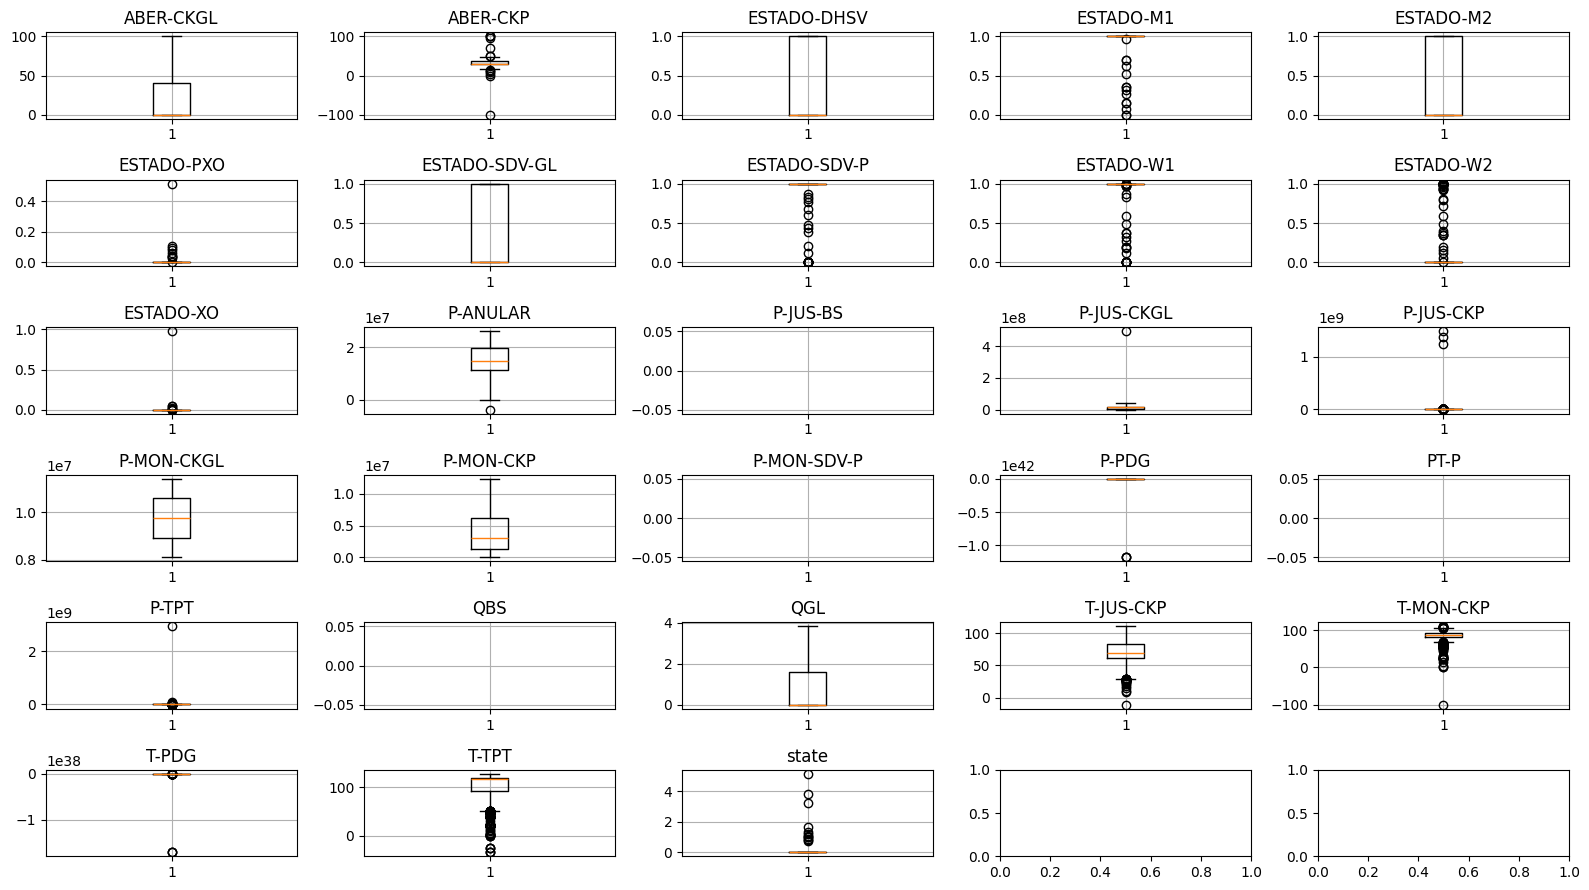

In [9]:
plot_boxes(distribution)

Affected Tags:
- `ABER-CKP`: Negative values
- `P-JUS-CKGL`: Readings capping scale
- `P-JUS-CKP`:  Readings capping scale
- `P-PDG`: same
- `P-TPT`: same
- `T-MON-CKP`: large negative values
- `T-PDG`: capping scale

The following solutions can be considered:
- Removing the affected files, which is easier but less accurate.
- Ignoring the apparently incorrect data, which is more complex and requires metadata.

---------------------------

## Data cleaning

To use the toolkit provided *data cleaning* options, we need to instantiate a **Transform** class (from TransformConfig) which creates a subclass from the ParquetDataset instance.

This class allows the use of pre processing and feature extraction properties. First, let's initialize a instance of **ParquetDataset**.

In [10]:
ds = ParquetDatasetConfig(path=dataset_path).build()

2026-04-06 13:11:24,171 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-06 13:11:24,172 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-06 13:11:24,173 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Now we will use the **TransformConfig** object, with the **CleanDataConfig** pre-processing option, to *fit* and *transform* our ParquetDataset object. 

In [11]:
dataset_processor = TransformConfig(pre_processing=CleanSignalsConfig()).build()

# Fit the processor to the dataset
dataset_processor.fit(ds)

# Transform the dataset using the fitted processor
transformed_ds = dataset_processor.transform(ds)

With the **CleanSignals** pre-processing we can observe in that: 

- Events whose statistics (standard deviation or average) fall outside a specified IQR thresholds may be considered faulty, and will be replaced with NaN values.

In [12]:
transformed_ds[0].signal

,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,ESTADO-XO,P-MON-CKP,P-PDG,P-TPT,T-JUS-CKP,T-TPT,state
timestamp,,,,,,,,,,,,,,,
2017-02-01 01:02:07,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1627884.0,NaN,10074540.0,84.64463,119.0781,<NA>
2017-02-01 01:02:08,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1633397.0,NaN,10074540.0,84.63828,119.0781,<NA>
2017-02-01 01:02:09,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1638909.0,NaN,10074540.0,84.63194,119.0781,<NA>
2017-02-01 01:02:10,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1644422.0,NaN,10074540.0,84.62558,119.0781,<NA>
2017-02-01 01:02:11,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1649934.0,NaN,10074540.0,84.61923,119.0781,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-01 06:59:56,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1504822.0,NaN,10014690.0,83.44021,119.0453,0
2017-02-01 06:59:57,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1510422.0,NaN,10014690.0,83.45413,119.0452,0
2017-02-01 06:59:58,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1516023.0,NaN,10014690.0,83.46806,119.0451,0


Now that we are familiar with the pre-processing usage, we will introduce the use of **Adapter** which allow us to use multiple pre-procesing or feature extraction classes in a custom combined way. 

For pre-processing we can import the **SequentialPreprocessingAdapterConfig** and for feature extraction we can import both **SequentialFeatureAdapterConfig** and **ConcatFeatureAdapterConfig**.

In [13]:
from ThreeWToolkit.preprocessing import SequentialPreprocessingAdapterConfig

Now let's create a custom pipeline for cleaning our dataset, using: 
- CleanSignals
- FillLabels
- ImputeMissing

In [14]:
dataset_processor = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[CleanSignalsConfig(), 
               FillLabelsConfig(), 
               ImputeMissingConfig()])
).build()

# Fit the processor to the dataset
dataset_processor.fit(ds)

# Transform the dataset using the fitted processor
transformed_ds = dataset_processor.transform(ds)

Let's repeat the process and gather the signal of each file and its average values and deviations:

In [15]:
averages, counts = [], []
for event in transformed_ds:
    signal = event.signal
    averages.append(signal.mean())
    counts.append(signal.count())

Tags that are mostly missing are removed.
Reading errors are sensibly removed.

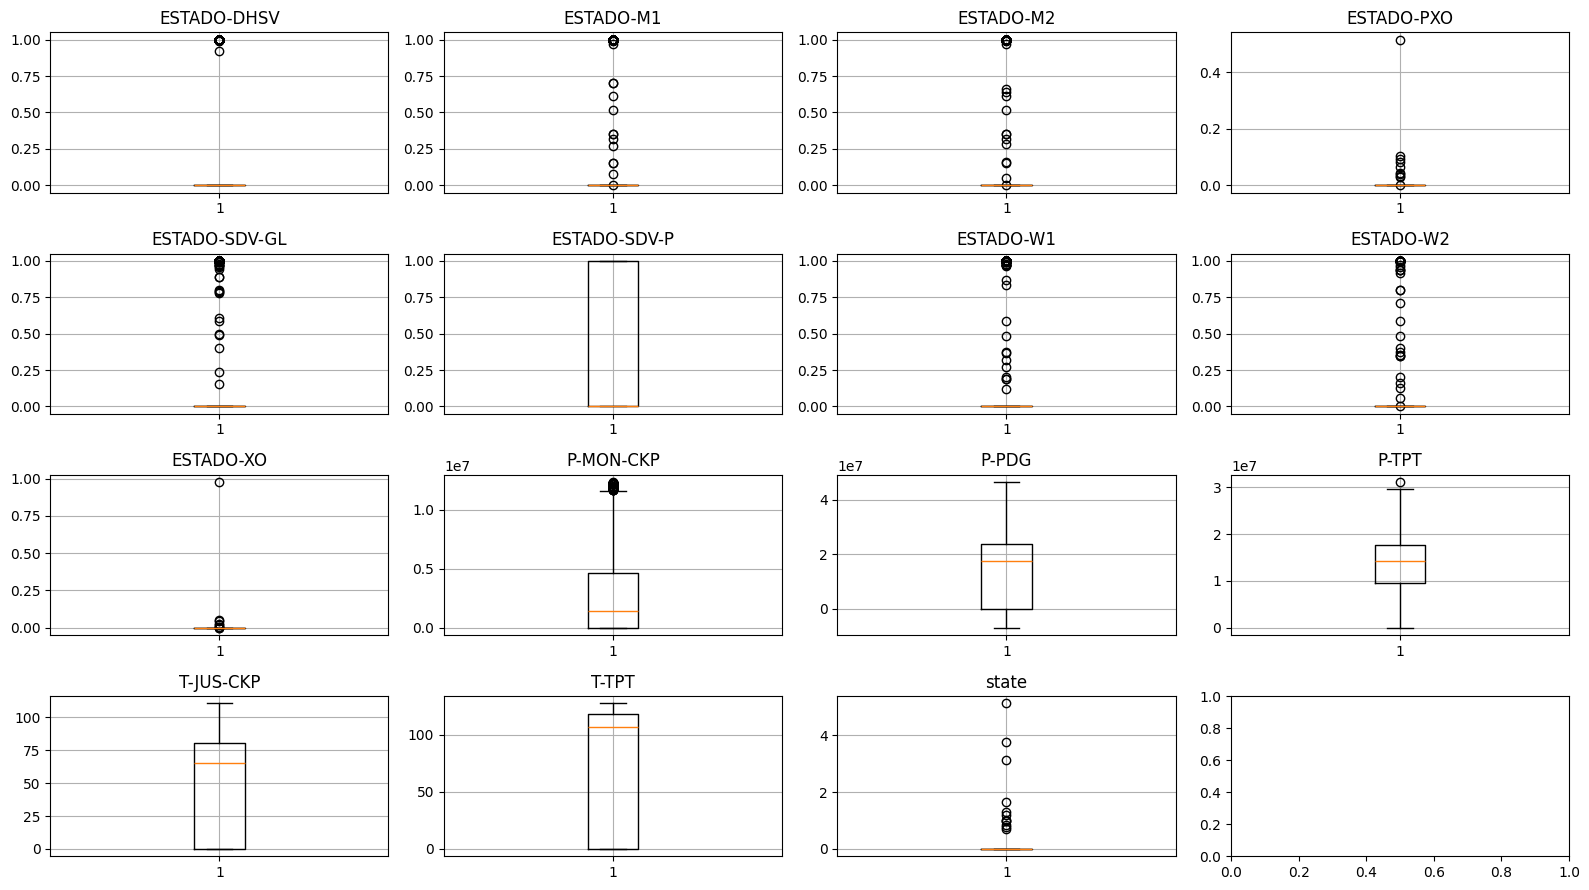

In [16]:
signals = counts[0].index
distribution = {s: [] for s in signals}

for s in signals:
    for a, c in zip(averages, counts):
        if c[s] != 0:
            distribution[s].append(a[s])
plot_boxes(distribution)

Do we have any missing data now? 🤔

In [17]:
total = sum(counts)
total

ESTADO-DHSV      76587318
ESTADO-M1        76587318
ESTADO-M2        76587318
ESTADO-PXO       76587318
ESTADO-SDV-GL    76587318
ESTADO-SDV-P     76587318
ESTADO-W1        76587318
ESTADO-W2        76587318
ESTADO-XO        76587318
P-MON-CKP        76587318
P-PDG            76587318
P-TPT            76587318
T-JUS-CKP        76587318
T-TPT            76587318
state            76587318
dtype: int64

🎉 No more missing data!

It is now possible to compute, for instance, global averages/deviations:

In [18]:
global_avg = sum(a.fillna(0) * c / total for a, c in zip(averages, counts))
global_avg

ESTADO-DHSV             0.103258
ESTADO-M1               0.198018
ESTADO-M2               0.073268
ESTADO-PXO              0.002094
ESTADO-SDV-GL           0.121678
ESTADO-SDV-P            0.289239
ESTADO-W1               0.173747
ESTADO-W2               0.057514
ESTADO-XO               0.000749
P-MON-CKP           2508965.6152
P-PDG            14155852.997264
P-TPT            12497210.363776
T-JUS-CKP              52.244405
T-TPT                  66.108191
state                   0.101929
dtype: Float64

and for the deviations:

In [19]:
counts, deviations = [], []
for event in transformed_ds:
    signal = event.signal
    deviations.append((signal - global_avg).pow(2).mean())
    counts.append(signal.count())

In [20]:
global_std = sum(d.fillna(0) * c / total for d, c in zip(deviations, counts)).pow(0.5)
global_std

ESTADO-DHSV             0.304295
ESTADO-M1               0.398506
ESTADO-M2               0.260573
ESTADO-PXO              0.045711
ESTADO-SDV-GL           0.326914
ESTADO-SDV-P            0.453409
ESTADO-W1               0.378892
ESTADO-W2               0.232821
ESTADO-XO               0.027364
P-MON-CKP         2960490.347842
P-PDG            12177573.018236
P-TPT               6958635.3571
T-JUS-CKP              34.206237
T-TPT                  53.600097
state                   0.700301
dtype: Float64